## How to use the dashboard

Run the notebook from the top using **Runtime → Run all**. Use the menu on the left to open Overview, Attacking Analysis, Defensive Analysis, Chance Creation, or Player Reports. In Player Reports, select a player from the dropdown to view their profile and season statistics.

# Manchester United Performance Dashboard | 2025–26

An interactive football analytics dashboard exploring Manchester United’s Premier League season. It includes team results, home and away performance, attacking and defensive analysis, chance creation, and player reports.

## Data sources

- Match results and team statistics: [Football-Data.co.uk](https://www.football-data.co.uk/englandm.php)
- Player gameweek statistics: [Premier League Stats dataset](https://github.com/imadeddine-belkat/Premier-League-Stats), based on public Fantasy Premier League API data.

## Notes

The player xG and xA figures are estimates from the player dataset. They describe expected goals and assists, not a complete measure of player quality. Player age is calculated as of 15 August 2025.

In [25]:
import pandas as pd

url = "https://www.football-data.co.uk/mmz4281/2526/E0.csv"
matches = pd.read_csv(url)

print("Dataset shape:", matches.shape)
print("Columns:", matches.columns.tolist())
print("Manchester United team names found:",
      [team for team in sorted(set(matches["HomeTeam"]) | set(matches["AwayTeam"]))
       if "United" in team or "Man" in team])

display(matches.head())

Dataset shape: (380, 132)
Columns: ['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BFDH', 'BFDD', 'BFDA', 'BMGMH', 'BMGMD', 'BMGMA', 'BVH', 'BVD', 'BVA', 'BWH', 'BWD', 'BWA', 'CLH', 'CLD', 'CLA', 'LBH', 'LBD', 'LBA', 'PSH', 'PSD', 'PSA', 'MaxH', 'MaxD', 'MaxA', 'AvgH', 'AvgD', 'AvgA', 'BFEH', 'BFED', 'BFEA', 'B365>2.5', 'B365<2.5', 'P>2.5', 'P<2.5', 'Max>2.5', 'Max<2.5', 'Avg>2.5', 'Avg<2.5', 'BFE>2.5', 'BFE<2.5', 'AHh', 'B365AHH', 'B365AHA', 'PAHH', 'PAHA', 'MaxAHH', 'MaxAHA', 'AvgAHH', 'AvgAHA', 'BFEAHH', 'BFEAHA', 'B365CH', 'B365CD', 'B365CA', 'BFDCH', 'BFDCD', 'BFDCA', 'BMGMCH', 'BMGMCD', 'BMGMCA', 'BVCH', 'BVCD', 'BVCA', 'BWCH', 'BWCD', 'BWCA', 'CLCH', 'CLCD', 'CLCA', 'LBCH', 'LBCD', 'LBCA', 'PSCH', 'PSCD', 'PSCA', 'MaxCH', 'MaxCD', 'MaxCA', 'AvgCH', 'AvgCD', 'AvgCA', 'BFECH', 'BFECD', 'BFECA', 'B365C>2.5', 'B365C<2.5', 'PC>

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,15/08/2025,20:00,Liverpool,Bournemouth,4,2,H,1,0,...,2.03,1.78,2.07,1.85,2.03,1.88,1.94,1.76,2.14,1.86
1,E0,16/08/2025,12:30,Aston Villa,Newcastle,0,0,D,0,0,...,2.05,1.80,2.02,1.89,2.06,1.80,1.95,1.74,2.14,1.86
2,E0,16/08/2025,15:00,Brighton,Fulham,1,1,D,0,0,...,1.83,2.03,1.93,2.00,1.84,2.03,1.80,1.96,1.91,2.08
3,E0,16/08/2025,15:00,Sunderland,West Ham,3,0,H,0,0,...,1.95,1.90,1.97,1.95,1.95,1.94,1.86,1.78,2.02,1.97
4,E0,16/08/2025,15:00,Tottenham,Burnley,3,0,H,1,0,...,1.98,1.88,1.99,1.93,1.98,1.91,1.88,1.83,2.07,1.92


In [26]:
import numpy as np

team = "Man United"

home = matches[matches["HomeTeam"] == team]
away = matches[matches["AwayTeam"] == team]

united_home = pd.DataFrame({
    "Date": home["Date"],
    "Venue": "Home",
    "Opponent": home["AwayTeam"],
    "GoalsFor": home["FTHG"],
    "GoalsAgainst": home["FTAG"],
    "ShotsFor": home["HS"],
    "ShotsAgainst": home["AS"],
    "ShotsOnTargetFor": home["HST"],
    "ShotsOnTargetAgainst": home["AST"],
    "CornersFor": home["HC"],
    "CornersAgainst": home["AC"],
})

united_away = pd.DataFrame({
    "Date": away["Date"],
    "Venue": "Away",
    "Opponent": away["HomeTeam"],
    "GoalsFor": away["FTAG"],
    "GoalsAgainst": away["FTHG"],
    "ShotsFor": away["AS"],
    "ShotsAgainst": away["HS"],
    "ShotsOnTargetFor": away["AST"],
    "ShotsOnTargetAgainst": away["HST"],
    "CornersFor": away["AC"],
    "CornersAgainst": away["HC"],
})

united = pd.concat([united_home, united_away], ignore_index=True)
united["Date"] = pd.to_datetime(united["Date"], dayfirst=True)
united = united.sort_values("Date").reset_index(drop=True)

united["Result"] = np.where(
    united["GoalsFor"] > united["GoalsAgainst"], "W",
    np.where(united["GoalsFor"] == united["GoalsAgainst"], "D", "L")
)
united["Points"] = united["Result"].map({"W": 3, "D": 1, "L": 0})

print("United matches:", len(united))
print(united["Result"].value_counts().reindex(["W", "D", "L"], fill_value=0))
print("Points:", united["Points"].sum())

display(united.head(10))

United matches: 38
Result
W    20
D    11
L     7
Name: count, dtype: int64
Points: 71


,Date,Venue,Opponent,GoalsFor,GoalsAgainst,ShotsFor,ShotsAgainst,ShotsOnTargetFor,ShotsOnTargetAgainst,CornersFor,CornersAgainst,Result,Points
0,2025-08-17,Home,Arsenal,0,1,22,9,7,3,3,4,L,0
1,2025-08-24,Away,Fulham,1,1,10,13,3,4,6,9,D,1
2,2025-08-30,Home,Burnley,3,2,26,6,6,3,7,1,W,3
3,2025-09-14,Away,Man City,0,3,12,13,2,6,4,2,L,0
4,2025-09-20,Home,Chelsea,2,1,11,5,4,1,5,5,W,3
5,2025-09-27,Away,Brentford,1,3,14,10,6,8,2,4,L,0
6,2025-10-04,Home,Sunderland,2,0,15,8,6,3,2,3,W,3
7,2025-10-19,Away,Liverpool,2,1,12,19,4,6,4,9,W,3
8,2025-10-25,Home,Brighton,4,2,13,17,9,5,1,6,W,3
9,2025-11-01,Away,Nott'm Forest,2,2,18,17,7,3,5,8,D,1


In [27]:
overall = {
    "Matches": len(united),
    "Wins": (united["Result"] == "W").sum(),
    "Draws": (united["Result"] == "D").sum(),
    "Losses": (united["Result"] == "L").sum(),
    "Points": united["Points"].sum(),
    "Points per match": round(united["Points"].mean(), 2),
    "Goals for": united["GoalsFor"].sum(),
    "Goals against": united["GoalsAgainst"].sum(),
    "Goal difference": united["GoalsFor"].sum() - united["GoalsAgainst"].sum(),
    "Shots": united["ShotsFor"].sum(),
    "Shots on target": united["ShotsOnTargetFor"].sum(),
    "Shot accuracy (%)": round(
        100 * united["ShotsOnTargetFor"].sum() / united["ShotsFor"].sum(), 1
    ),
}

display(pd.DataFrame(list(overall.items()), columns=["Metric", "Value"]))

venue_summary = (
    united.groupby("Venue")
    .agg(
        Matches=("Result", "size"),
        Wins=("Result", lambda x: (x == "W").sum()),
        Draws=("Result", lambda x: (x == "D").sum()),
        Losses=("Result", lambda x: (x == "L").sum()),
        Points=("Points", "sum"),
        GoalsFor=("GoalsFor", "sum"),
        GoalsAgainst=("GoalsAgainst", "sum"),
        Shots=("ShotsFor", "sum"),
        ShotsOnTarget=("ShotsOnTargetFor", "sum"),
    )
    .reset_index()
)

venue_summary["PointsPerMatch"] = (
    venue_summary["Points"] / venue_summary["Matches"]
).round(2)

display(venue_summary)

,Metric,Value
0,Matches,38.00
1,Wins,20.00
2,Draws,11.00
3,Losses,7.00
4,Points,71.00
5,Points per match,1.87
6,Goals for,69.00
7,Goals against,50.00
8,Goal difference,19.00
9,Shots,596.00


,Venue,Matches,Wins,Draws,Losses,Points,GoalsFor,GoalsAgainst,Shots,ShotsOnTarget,PointsPerMatch
0,Away,19,7,8,4,29,30,26,256,86,1.53
1,Home,19,13,3,3,42,39,24,340,130,2.21


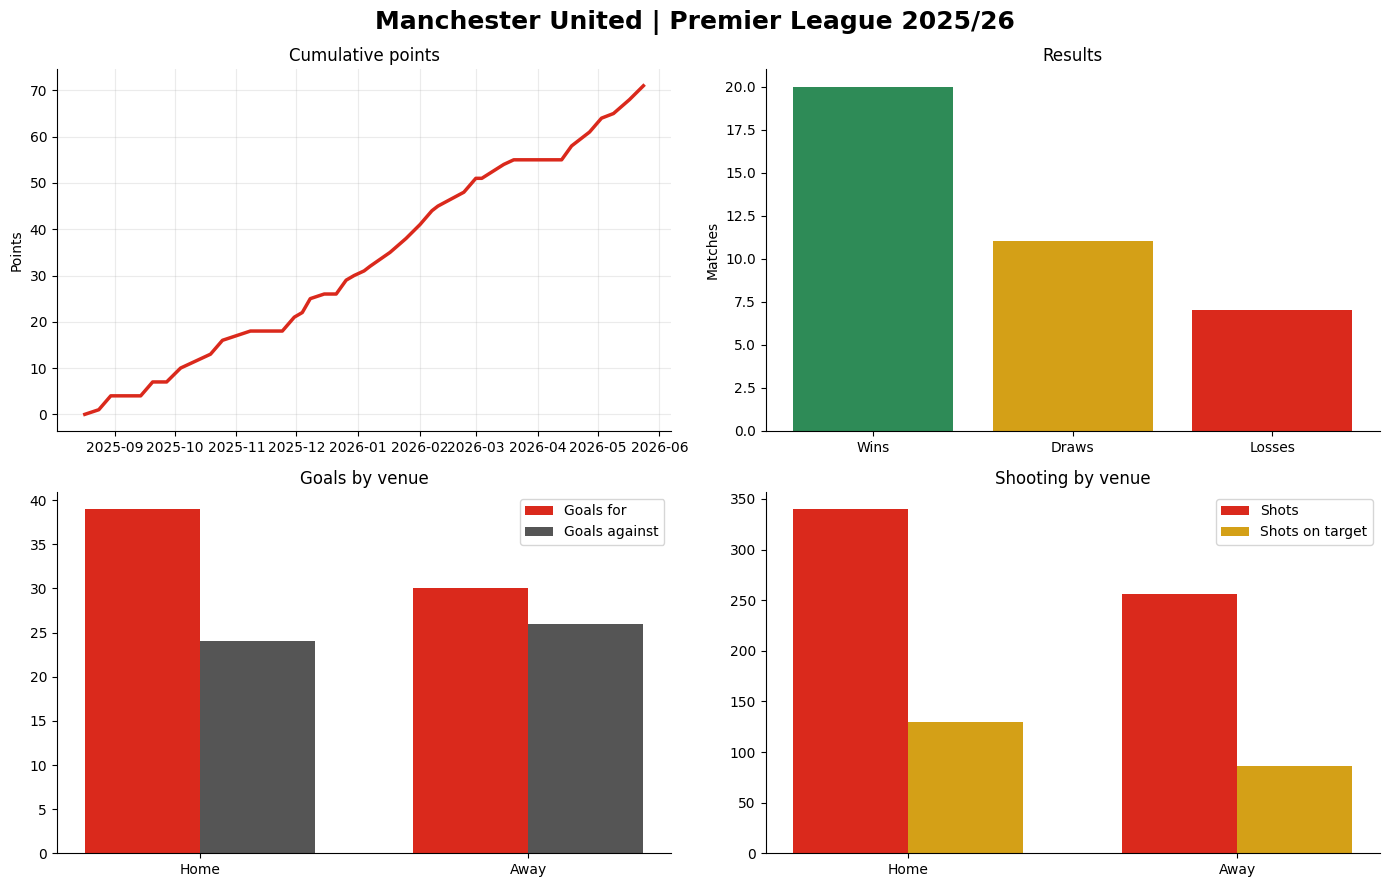

In [28]:
import matplotlib.pyplot as plt

united["CumulativePoints"] = united["Points"].cumsum()
venue = venue_summary.set_index("Venue").loc[["Home", "Away"]]

fig, ax = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    "Manchester United | Premier League 2025/26",
    fontsize=18, fontweight="bold"
)

# 1. Points earned through the season
ax[0, 0].plot(
    united["Date"], united["CumulativePoints"],
    color="#DA291C", linewidth=2.5
)
ax[0, 0].set_title("Cumulative points")
ax[0, 0].set_ylabel("Points")
ax[0, 0].grid(alpha=0.25)

# 2. Wins, draws, and losses
result_counts = united["Result"].value_counts().reindex(["W", "D", "L"], fill_value=0)
ax[0, 1].bar(
    ["Wins", "Draws", "Losses"],
    result_counts.values,
    color=["#2E8B57", "#D4A017", "#DA291C"]
)
ax[0, 1].set_title("Results")
ax[0, 1].set_ylabel("Matches")

# 3. Goals scored and conceded by venue
x = range(len(venue))
width = 0.35
ax[1, 0].bar(
    [i - width / 2 for i in x], venue["GoalsFor"],
    width, label="Goals for", color="#DA291C"
)
ax[1, 0].bar(
    [i + width / 2 for i in x], venue["GoalsAgainst"],
    width, label="Goals against", color="#555555"
)
ax[1, 0].set_xticks(list(x), venue.index)
ax[1, 0].set_title("Goals by venue")
ax[1, 0].legend()

# 4. Shots and shots on target by venue
ax[1, 1].bar(
    [i - width / 2 for i in x], venue["Shots"],
    width, label="Shots", color="#DA291C"
)
ax[1, 1].bar(
    [i + width / 2 for i in x], venue["ShotsOnTarget"],
    width, label="Shots on target", color="#D4A017"
)
ax[1, 1].set_xticks(list(x), venue.index)
ax[1, 1].set_title("Shooting by venue")
ax[1, 1].legend()

for axis in ax.flat:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [29]:
total_shots = united["ShotsFor"].sum()
shots_on_target = united["ShotsOnTargetFor"].sum()
goals = united["GoalsFor"].sum()

print(f"Shots on target rate: {shots_on_target / total_shots:.1%}")
print(f"Goal conversion rate: {goals / total_shots:.1%}")
print(f"Goals per shot on target: {goals / shots_on_target:.1%}")

venue_summary["ShotsOnTargetRatePct"] = (
    100 * venue_summary["ShotsOnTarget"] / venue_summary["Shots"]
).round(1)

venue_summary["GoalConversionPct"] = (
    100 * venue_summary["GoalsFor"] / venue_summary["Shots"]
).round(1)

display(venue_summary[
    ["Venue", "Shots", "ShotsOnTarget", "GoalsFor",
     "ShotsOnTargetRatePct", "GoalConversionPct"]
])

Shots on target rate: 36.2%
Goal conversion rate: 11.6%
Goals per shot on target: 31.9%


,Venue,Shots,ShotsOnTarget,GoalsFor,ShotsOnTargetRatePct,GoalConversionPct
0,Away,256,86,30,33.6,11.7
1,Home,340,130,39,38.2,11.5


In [30]:
attack_defense = (
    united.groupby("Venue")
    .agg(
        Matches=("Date", "count"),
        GoalsFor=("GoalsFor", "sum"),
        GoalsAgainst=("GoalsAgainst", "sum"),
        ShotsFor=("ShotsFor", "sum"),
        ShotsAgainst=("ShotsAgainst", "sum"),
        ShotsOnTargetFor=("ShotsOnTargetFor", "sum"),
        ShotsOnTargetAgainst=("ShotsOnTargetAgainst", "sum"),
    )
)

for column in [
    "GoalsFor", "GoalsAgainst", "ShotsFor", "ShotsAgainst",
    "ShotsOnTargetFor", "ShotsOnTargetAgainst"
]:
    attack_defense[column + "PerMatch"] = (
        attack_defense[column] / attack_defense["Matches"]
    ).round(2)

display(attack_defense[[
    "Matches",
    "GoalsForPerMatch", "GoalsAgainstPerMatch",
    "ShotsForPerMatch", "ShotsAgainstPerMatch",
    "ShotsOnTargetForPerMatch", "ShotsOnTargetAgainstPerMatch"
]])


,Matches,GoalsForPerMatch,GoalsAgainstPerMatch,ShotsForPerMatch,ShotsAgainstPerMatch,ShotsOnTargetForPerMatch,ShotsOnTargetAgainstPerMatch
Venue,,,,,,,
Away,19,1.58,1.37,13.47,12.89,4.53,3.89
Home,19,2.05,1.26,17.89,10.32,6.84,3.53


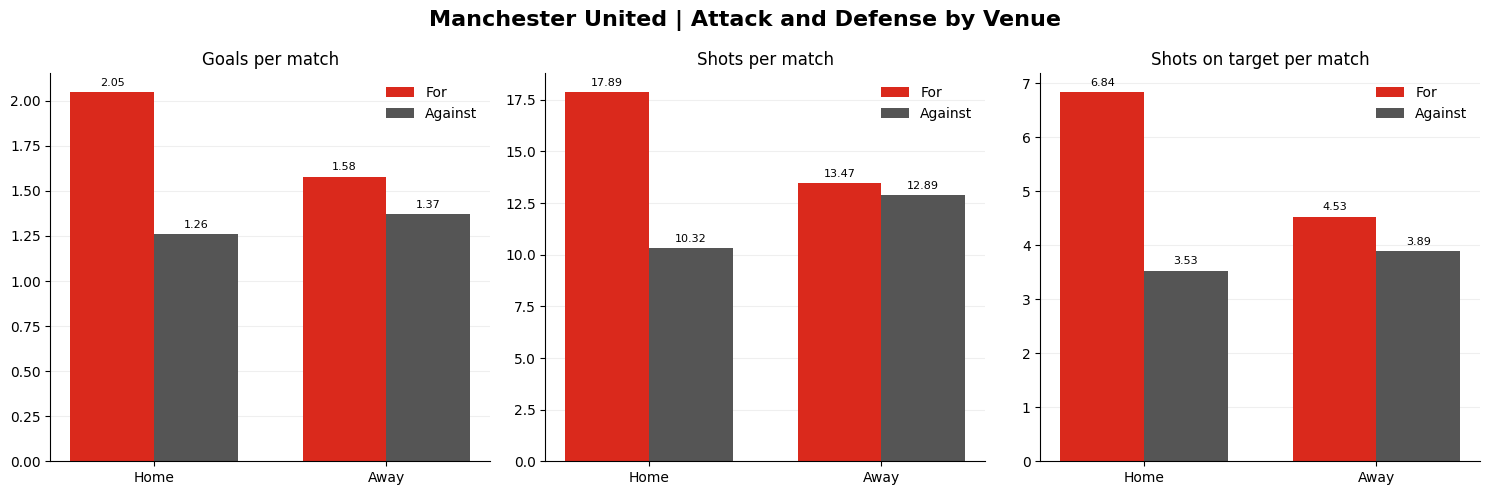

In [31]:
import numpy as np
import matplotlib.pyplot as plt

plot_data = attack_defense.loc[["Home", "Away"]]

charts = [
    ("Goals per match", "GoalsForPerMatch", "GoalsAgainstPerMatch"),
    ("Shots per match", "ShotsForPerMatch", "ShotsAgainstPerMatch"),
    ("Shots on target per match",
     "ShotsOnTargetForPerMatch", "ShotsOnTargetAgainstPerMatch"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "Manchester United | Attack and Defense by Venue",
    fontsize=16, fontweight="bold"
)

x = np.arange(len(plot_data))
width = 0.36

for axis, (title, for_col, against_col) in zip(axes, charts):
    bars_for = axis.bar(
        x - width / 2, plot_data[for_col],
        width, label="For", color="#DA291C"
    )
    bars_against = axis.bar(
        x + width / 2, plot_data[against_col],
        width, label="Against", color="#555555"
    )

    axis.set_title(title)
    axis.set_xticks(x, plot_data.index)
    axis.legend(frameon=False)
    axis.bar_label(bars_for, fmt="%.2f", padding=3, fontsize=8)
    axis.bar_label(bars_against, fmt="%.2f", padding=3, fontsize=8)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.grid(axis="y", alpha=0.2)
    axis.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [32]:
home_teams = pd.DataFrame({
    "Team": matches["HomeTeam"],
    "GoalsFor": matches["FTHG"],
    "GoalsAgainst": matches["FTAG"],
    "ShotsFor": matches["HS"],
    "ShotsAgainst": matches["AS"],
    "ShotsOnTargetFor": matches["HST"],
    "ShotsOnTargetAgainst": matches["AST"],
})

away_teams = pd.DataFrame({
    "Team": matches["AwayTeam"],
    "GoalsFor": matches["FTAG"],
    "GoalsAgainst": matches["FTHG"],
    "ShotsFor": matches["AS"],
    "ShotsAgainst": matches["HS"],
    "ShotsOnTargetFor": matches["AST"],
    "ShotsOnTargetAgainst": matches["HST"],
})

team_matches = pd.concat([home_teams, away_teams], ignore_index=True)

team_matches["Win"] = (
    team_matches["GoalsFor"] > team_matches["GoalsAgainst"]
).astype(int)
team_matches["Draw"] = (
    team_matches["GoalsFor"] == team_matches["GoalsAgainst"]
).astype(int)
team_matches["Loss"] = (
    team_matches["GoalsFor"] < team_matches["GoalsAgainst"]
).astype(int)
team_matches["Points"] = team_matches["Win"] * 3 + team_matches["Draw"]

league_summary = (
    team_matches.groupby("Team")
    .agg(
        Matches=("Team", "size"),
        Wins=("Win", "sum"),
        Draws=("Draw", "sum"),
        Losses=("Loss", "sum"),
        Points=("Points", "sum"),
        GoalsFor=("GoalsFor", "sum"),
        GoalsAgainst=("GoalsAgainst", "sum"),
        ShotsFor=("ShotsFor", "sum"),
        ShotsOnTargetFor=("ShotsOnTargetFor", "sum"),
    )
    .reset_index()
)

league_summary["GoalDifference"] = (
    league_summary["GoalsFor"] - league_summary["GoalsAgainst"]
)

league_summary = league_summary.sort_values(
    ["Points", "GoalDifference", "GoalsFor"],
    ascending=[False, False, False]
).reset_index(drop=True)

league_summary.insert(0, "Position", range(1, len(league_summary) + 1))

display(league_summary.head(10))
display(league_summary[league_summary["Team"] == "Man United"])

,Position,Team,Matches,Wins,Draws,Losses,Points,GoalsFor,GoalsAgainst,ShotsFor,ShotsOnTargetFor,GoalDifference
0,1,Arsenal,38,26,7,5,85,71,27,552,186,44
1,2,Man City,38,23,9,6,78,77,35,595,205,42
2,3,Man United,38,20,11,7,71,69,50,596,216,19
3,4,Aston Villa,38,19,8,11,65,56,49,483,170,7
4,5,Liverpool,38,17,9,12,60,63,53,588,175,10
5,6,Bournemouth,38,13,18,7,57,58,54,525,178,4
6,7,Sunderland,38,14,12,12,54,42,48,395,126,-6
7,8,Brighton,38,14,11,13,53,52,46,495,176,6
8,9,Brentford,38,14,11,13,53,55,52,405,147,3
9,10,Chelsea,38,14,10,14,52,58,52,511,164,6


,Position,Team,Matches,Wins,Draws,Losses,Points,GoalsFor,GoalsAgainst,ShotsFor,ShotsOnTargetFor,GoalDifference
2,3,Man United,38,20,11,7,71,69,50,596,216,19


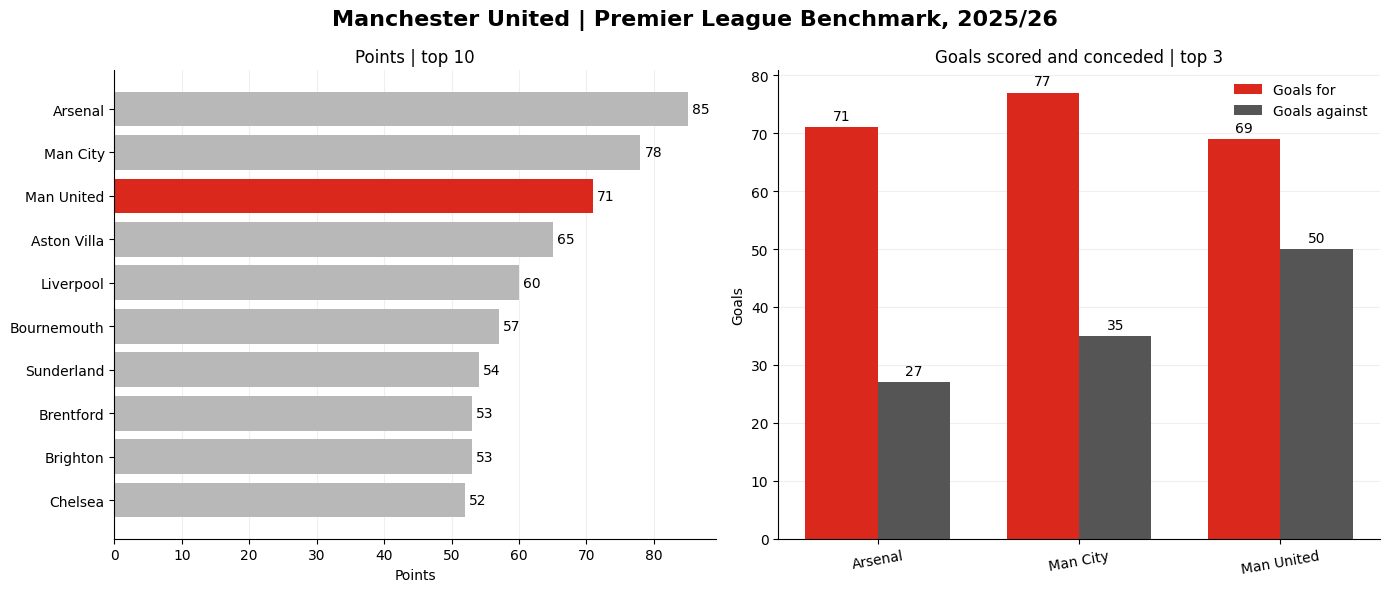

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Manchester United | Premier League Benchmark, 2025/26",
    fontsize=16, fontweight="bold"
)

# Points: top 10, with United highlighted
top10 = league_summary.head(10).sort_values("Points")
colors = [
    "#DA291C" if team == "Man United" else "#B8B8B8"
    for team in top10["Team"]
]

bars = axes[0].barh(top10["Team"], top10["Points"], color=colors)
axes[0].bar_label(bars, padding=3)
axes[0].set_title("Points | top 10")
axes[0].set_xlabel("Points")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].grid(axis="x", alpha=0.2)
axes[0].set_axisbelow(True)

# Goals scored and conceded: top 3
top3 = league_summary.head(3).set_index("Team")
x = np.arange(len(top3))
width = 0.36

for_bars = axes[1].bar(
    x - width / 2, top3["GoalsFor"],
    width, label="Goals for", color="#DA291C"
)
against_bars = axes[1].bar(
    x + width / 2, top3["GoalsAgainst"],
    width, label="Goals against", color="#555555"
)

axes[1].set_xticks(x, top3.index, rotation=10)
axes[1].set_title("Goals scored and conceded | top 3")
axes[1].set_ylabel("Goals")
axes[1].legend(frameon=False)
axes[1].bar_label(for_bars, padding=3)
axes[1].bar_label(against_bars, padding=3)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].grid(axis="y", alpha=0.2)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()


In [34]:
player_url = (
    "https://raw.githubusercontent.com/imadeddine-belkat/"
    "Premier-League-Stats/main/fpl_scraper/fpl_stats/"
    "_merged/players/2025-26_all_players_gw.csv"
)

player_gameweeks = pd.read_csv(player_url)

print("Rows and columns:", player_gameweeks.shape)
print("Columns:", player_gameweeks.columns.tolist())
display(player_gameweeks.head(8))

Rows and columns: (29747, 40)
Columns: ['element', 'position', 'player_code', 'first_name', 'second_name', 'fixture_code', 'total_points', 'modified', 'minutes', 'goals_scored', 'assists', 'clean_sheets', 'goals_conceded', 'own_goals', 'penalties_saved', 'penalties_missed', 'yellow_cards', 'red_cards', 'saves', 'bonus', 'bps', 'influence', 'creativity', 'threat', 'ict_index', 'clearances_blocks_interceptions', 'recoveries', 'tackles', 'defensive_contribution', 'starts', 'expected_goals', 'expected_assists', 'expected_goal_involvements', 'expected_goals_conceded', 'value', 'transfers_balance', 'selected', 'transfers_in', 'transfers_out', 'team_code']


,element,position,player_code,first_name,second_name,fixture_code,total_points,modified,minutes,goals_scored,...,expected_goals,expected_assists,expected_goal_involvements,expected_goals_conceded,value,transfers_balance,selected,transfers_in,transfers_out,team_code
0,1,GKP,154561,David,Raya Martín,2561903,10,False,90,0,...,0.0,0.00,0.00,1.52,55,0,1531911,0,0,3
1,1,GKP,154561,David,Raya Martín,2561906,6,False,90,0,...,0.0,0.00,0.00,0.17,55,218659,2284634,277339,58680,3
2,1,GKP,154561,David,Raya Martín,2561919,2,False,90,0,...,0.0,0.02,0.02,0.52,55,-12311,2406964,146739,159050,3
3,1,GKP,154561,David,Raya Martín,2561926,6,False,90,0,...,0.0,0.00,0.00,0.20,55,171289,2765759,289041,117752,3
4,1,GKP,154561,David,Raya Martín,2561936,2,False,90,0,...,0.0,0.01,0.01,0.89,55,-9786,2762632,98100,107886,3
5,1,GKP,154561,David,Raya Martín,2561952,2,False,90,0,...,0.0,0.01,0.01,0.61,56,227251,3029654,357846,130595,3
6,1,GKP,154561,David,Raya Martín,2561956,6,False,90,0,...,0.0,0.00,0.00,0.49,56,212315,3297838,287510,75195,3
7,1,GKP,154561,David,Raya Martín,2561968,6,False,90,0,...,0.0,0.00,0.00,0.44,57,120482,3447590,208192,87710,3


In [35]:
import json
import requests

print("Team-related columns:",
      [column for column in player_gameweeks.columns
       if "team" in column.lower()])

teams_index_url = (
    "https://raw.githubusercontent.com/imadeddine-belkat/"
    "Premier-League-Stats/main/fpl_scraper/fpl_stats/"
    "_index/_teams_index.json"
)

response = requests.get(teams_index_url)
print("Index download status:", response.status_code)

teams_index = response.json()
print(json.dumps(teams_index, indent=2)[:2000])

Team-related columns: ['team_code']
Index download status: 200
{
  "1": {
    "2025-26": {
      "id": 14,
      "name": "Man Utd",
      "short_name": "MUN"
    },
    "2026-27": {
      "id": 16,
      "name": "Man Utd",
      "short_name": "MUN"
    }
  },
  "2": {
    "2025-26": {
      "id": 11,
      "name": "Leeds",
      "short_name": "LEE"
    },
    "2026-27": {
      "id": 13,
      "name": "Leeds",
      "short_name": "LEE"
    }
  },
  "3": {
    "2025-26": {
      "id": 1,
      "name": "Arsenal",
      "short_name": "ARS"
    },
    "2026-27": {
      "id": 1,
      "name": "Arsenal",
      "short_name": "ARS"
    }
  },
  "4": {
    "2025-26": {
      "id": 15,
      "name": "Newcastle",
      "short_name": "NEW"
    },
    "2026-27": {
      "id": 17,
      "name": "Newcastle",
      "short_name": "NEW"
    }
  },
  "6": {
    "2025-26": {
      "id": 18,
      "name": "Spurs",
      "short_name": "TOT"
    },
    "2026-27": {
      "id": 19,
      "name": "Spurs",
   

In [36]:
team_map = {
    str(code): seasons["2025-26"]["name"]
    for code, seasons in teams_index.items()
    if "2025-26" in seasons
}

player_gameweeks["team_code_key"] = (
    pd.to_numeric(player_gameweeks["team_code"], errors="coerce")
    .astype("Int64")
    .astype(str)
)

player_gameweeks["team_name"] = (
    player_gameweeks["team_code_key"].map(team_map)
)

print("Team names containing 'Man':",
      sorted(name for name in player_gameweeks["team_name"].dropna().unique()
             if "man" in name.lower()))

united_player_gameweeks = player_gameweeks[
    player_gameweeks["team_name"].str.contains(
        r"manchester united|man utd|man united",
        case=False,
        na=False
    )
].copy()

print("United player-gameweek rows:", len(united_player_gameweeks))
display(united_player_gameweeks[
    ["first_name", "second_name", "position", "team_name"]
].drop_duplicates().head(15))

Team names containing 'Man': ['Man City', 'Man Utd']
United player-gameweek rows: 1574


,first_name,second_name,position,team_name
19049,Bryan,Mbeumo,MID,Man Utd
19087,Altay,Bayındır,GKP,Man Utd
19125,André,Onana,GKP,Man Utd
19163,Elyh,Harrison,GKP,Man Utd
19201,Tom,Heaton,GKP,Man Utd
19239,Dermot,Mee,GKP,Man Utd
19277,Matthijs,de Ligt,DEF,Man Utd
19315,Lisandro,Martínez,DEF,Man Utd
19353,Noussair,Mazraoui,DEF,Man Utd
19391,Diego,León Blanco,DEF,Man Utd


In [37]:
player_season = (
    united_player_gameweeks
    .groupby(
        ["element", "first_name", "second_name", "position"],
        as_index=False
    )
    .agg(
        Appearances=("minutes", lambda values: (values > 0).sum()),
        Minutes=("minutes", "sum"),
        Goals=("goals_scored", "sum"),
        Assists=("assists", "sum"),
        xG=("expected_goals", "sum"),
        xA=("expected_assists", "sum"),
        FPLPoints=("total_points", "sum"),
    )
)

player_season["GoalContributions"] = (
    player_season["Goals"] + player_season["Assists"]
)

player_season["GoalsPer90"] = (
    90 * player_season["Goals"] / player_season["Minutes"].replace(0, np.nan)
).round(2)

player_season["AssistsPer90"] = (
    90 * player_season["Assists"] / player_season["Minutes"].replace(0, np.nan)
).round(2)

player_season["xG"] = player_season["xG"].round(2)
player_season["xA"] = player_season["xA"].round(2)

display(
    player_season
    .sort_values(["GoalContributions", "Minutes"], ascending=[False, False])
    [[
        "first_name", "second_name", "position", "Appearances",
        "Minutes", "Goals", "Assists", "GoalContributions",
        "xG", "xA", "GoalsPer90", "AssistsPer90", "FPLPoints"
    ]]
    .head(15)
)

,first_name,second_name,position,Appearances,Minutes,Goals,Assists,GoalContributions,xG,xA,GoalsPer90,AssistsPer90,FPLPoints
19,Bruno,Borges Fernandes,MID,35,3065,9,24,33,10.79,12.28,0.26,0.70,235
0,Bryan,Mbeumo,MID,33,2611,11,3,14,11.98,4.99,0.38,0.10,148
20,Matheus,Santos Carneiro da Cunha,MID,33,2493,10,4,14,6.90,3.36,0.36,0.14,143
25,Carlos Henrique,Casimiro,MID,34,2575,9,4,13,5.44,3.17,0.31,0.14,165
37,Benjamin,Sesko,FWD,30,1630,11,2,13,9.21,0.28,0.61,0.11,111
11,Patrick,Dorgu,DEF,26,1440,4,4,8,2.39,1.84,0.25,0.25,95
10,Diogo,Dalot Teixeira,DEF,34,2609,1,6,7,1.93,2.57,0.03,0.21,111
22,Amad,Diallo,MID,32,2339,2,5,7,5.46,4.74,0.08,0.19,91
26,Kobbie,Mainoo,MID,28,1653,1,2,3,0.48,1.27,0.05,0.11,73
12,Harry,Maguire,DEF,23,1649,1,2,3,1.12,0.50,0.05,0.11,90


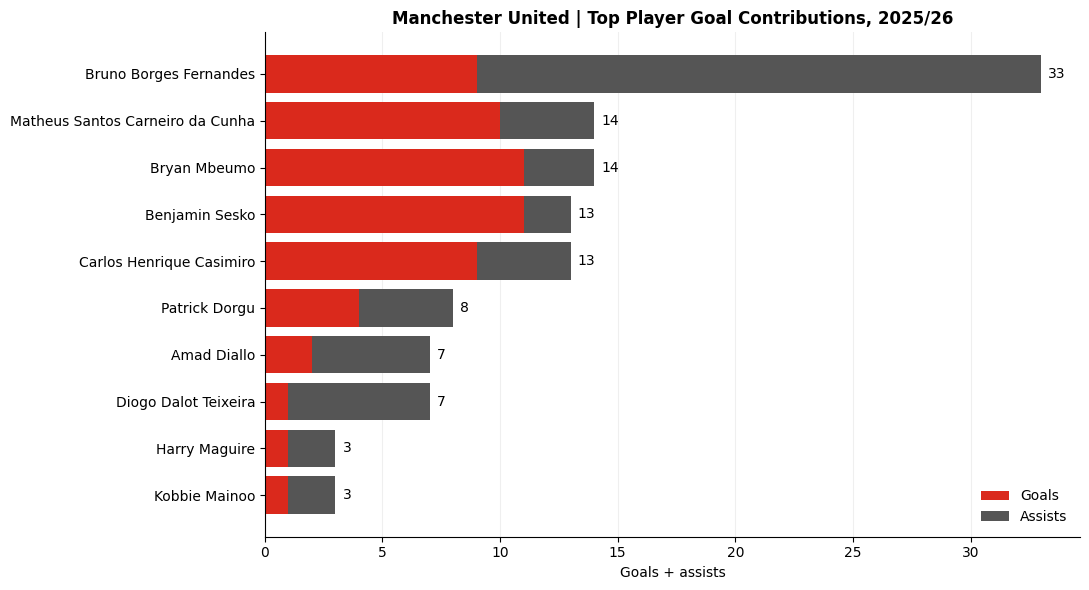

In [38]:
leaders = player_season.copy()
leaders["Player"] = leaders["first_name"] + " " + leaders["second_name"]
leaders = (
    leaders.sort_values("GoalContributions", ascending=False)
    .head(10)
    .sort_values("GoalContributions")
)

fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(leaders))

ax.barh(
    y, leaders["Goals"],
    color="#DA291C", label="Goals"
)
ax.barh(
    y, leaders["Assists"],
    left=leaders["Goals"],
    color="#555555", label="Assists"
)

ax.set_yticks(y, leaders["Player"])
ax.set_xlabel("Goals + assists")
ax.set_title(
    "Manchester United | Top Player Goal Contributions, 2025/26",
    fontweight="bold"
)
ax.legend(frameon=False)

for index, total in enumerate(leaders["GoalContributions"]):
    ax.text(total + 0.3, index, str(total), va="center")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

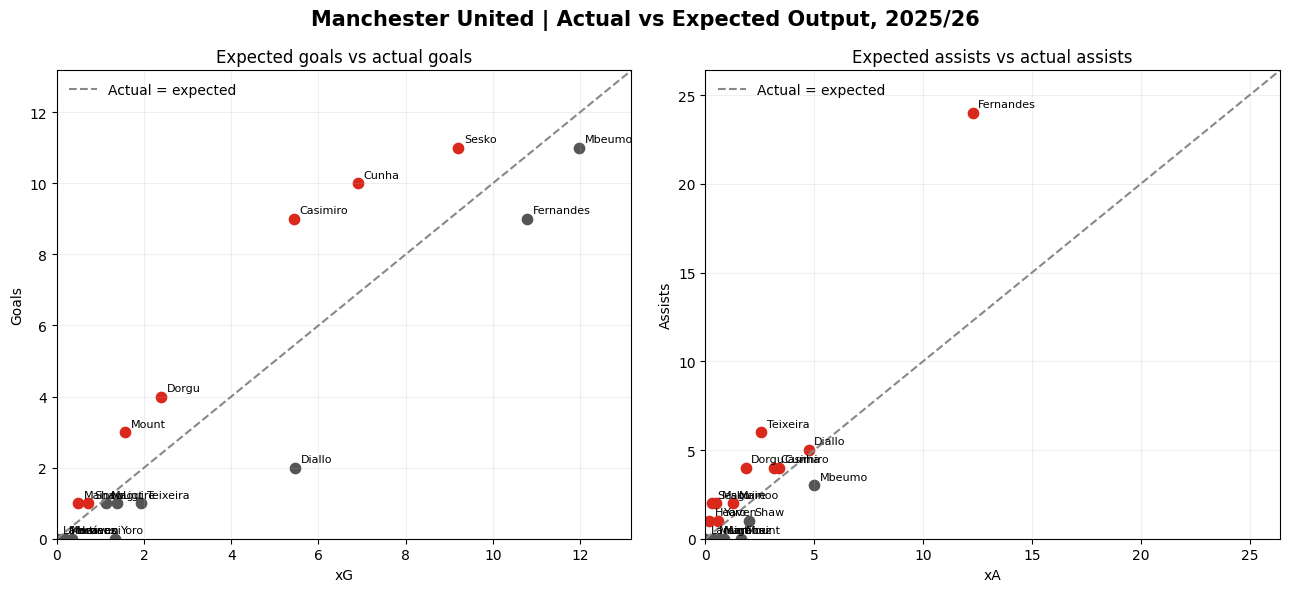

In [39]:
eligible = player_season[player_season["Minutes"] >= 900].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

comparisons = [
    ("xG", "Goals", "Expected goals vs actual goals"),
    ("xA", "Assists", "Expected assists vs actual assists"),
]

for ax, (expected_col, actual_col, title) in zip(axes, comparisons):
    limit = max(
        eligible[expected_col].max(),
        eligible[actual_col].max()
    ) * 1.1

    ax.plot(
        [0, limit], [0, limit],
        linestyle="--", color="#888888",
        label="Actual = expected"
    )

    for _, player in eligible.iterrows():
        color = "#DA291C" if player[actual_col] > player[expected_col] else "#555555"
        ax.scatter(
            player[expected_col], player[actual_col],
            color=color, s=55
        )
        ax.annotate(
            player["second_name"].split()[-1],
            (player[expected_col], player[actual_col]),
            xytext=(4, 4), textcoords="offset points",
            fontsize=8
        )

    ax.set_xlim(0, limit)
    ax.set_ylim(0, limit)
    ax.set_xlabel(expected_col)
    ax.set_ylabel(actual_col)
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)

fig.suptitle(
    "Manchester United | Actual vs Expected Output, 2025/26",
    fontsize=15, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [40]:
player_insight = player_season[
    player_season["Minutes"] >= 900
].copy()

player_insight["GoalsMinusXG"] = (
    player_insight["Goals"] - player_insight["xG"]
).round(2)

player_insight["AssistsMinusXA"] = (
    player_insight["Assists"] - player_insight["xA"]
).round(2)

player_insight["Player"] = (
    player_insight["first_name"] + " " + player_insight["second_name"]
)

display(
    player_insight
    .sort_values("GoalContributions", ascending=False)
    [[
        "Player", "Minutes", "Goals", "xG", "GoalsMinusXG",
        "Assists", "xA", "AssistsMinusXA", "GoalContributions"
    ]]
    .head(12)
)

,Player,Minutes,Goals,xG,GoalsMinusXG,Assists,xA,AssistsMinusXA,GoalContributions
19,Bruno Borges Fernandes,3065,9,10.79,-1.79,24,12.28,11.72,33
0,Bryan Mbeumo,2611,11,11.98,-0.98,3,4.99,-1.99,14
20,Matheus Santos Carneiro da Cunha,2493,10,6.90,3.10,4,3.36,0.64,14
25,Carlos Henrique Casimiro,2575,9,5.44,3.56,4,3.17,0.83,13
37,Benjamin Sesko,1630,11,9.21,1.79,2,0.28,1.72,13
11,Patrick Dorgu,1440,4,2.39,1.61,4,1.84,2.16,8
22,Amad Diallo,2339,2,5.46,-3.46,5,4.74,0.26,7
10,Diogo Dalot Teixeira,2609,1,1.93,-0.93,6,2.57,3.43,7
26,Kobbie Mainoo,1653,1,0.48,0.52,2,1.27,0.73,3
12,Harry Maguire,1649,1,1.12,-0.12,2,0.50,1.50,3


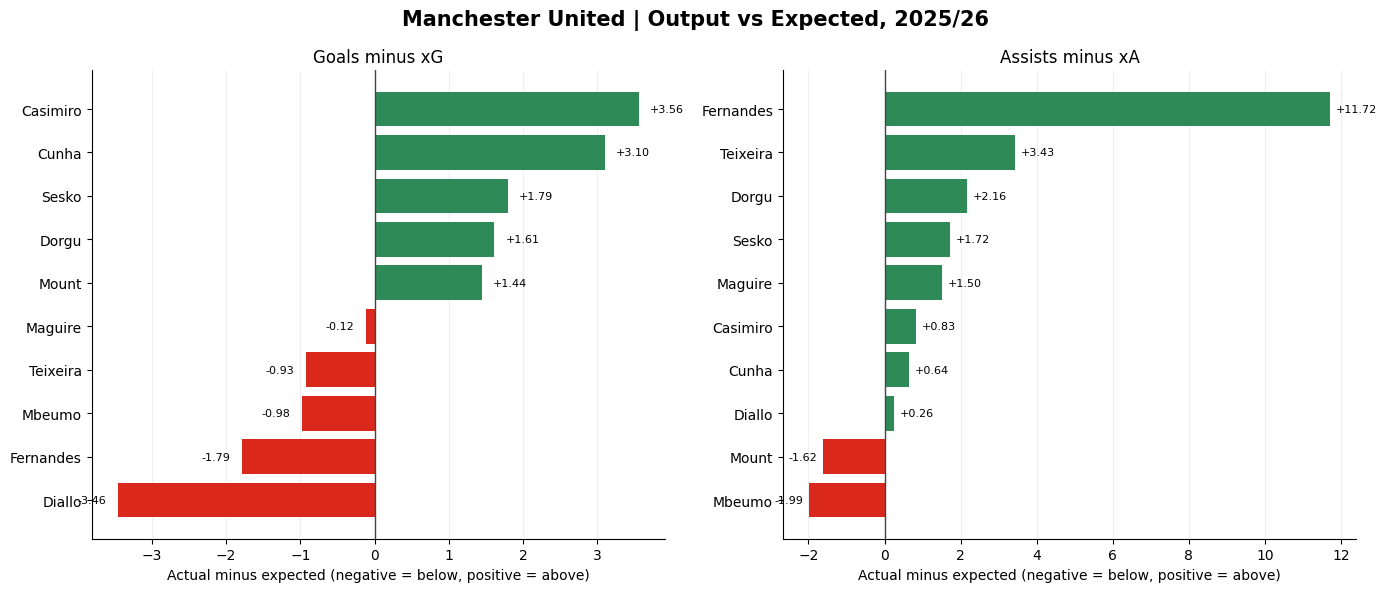

In [41]:
selected = (
    player_insight
    .nlargest(10, "GoalContributions")
    .copy()
)
selected["ShortName"] = selected["second_name"].str.split().str[-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, title in [
    (axes[0], "GoalsMinusXG", "Goals minus xG"),
    (axes[1], "AssistsMinusXA", "Assists minus xA"),
]:
    plot_df = selected.sort_values(metric)
    values = plot_df[metric]
    colors = ["#2E8B57" if value >= 0 else "#DA291C" for value in values]

    bars = ax.barh(plot_df["ShortName"], values, color=colors)
    ax.axvline(0, color="#444444", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Actual minus expected (negative = below, positive = above)")
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bar, value in zip(bars, values):
        offset = 0.15 if value >= 0 else -0.15
        alignment = "left" if value >= 0 else "right"
        ax.text(
            value + offset,
            bar.get_y() + bar.get_height() / 2,
            f"{value:+.2f}",
            va="center",
            ha=alignment,
            fontsize=8
        )

fig.suptitle(
    "Manchester United | Output vs Expected, 2025/26",
    fontsize=15, fontweight="bold"
)
plt.tight_layout()
plt.show()

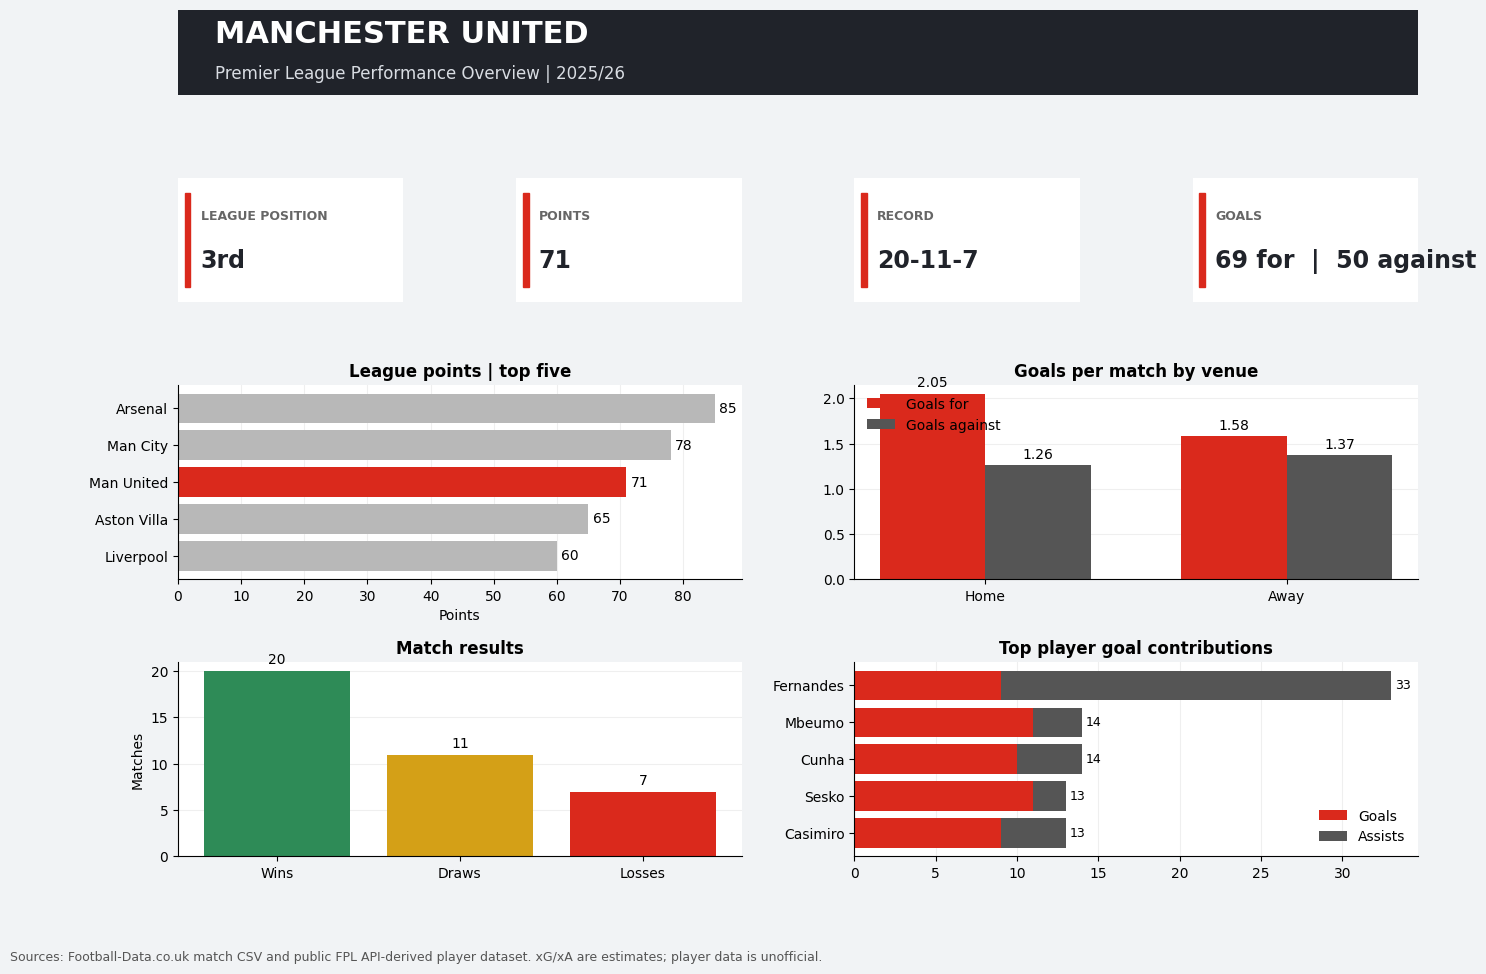

Saved dashboard image: manchester_united_2025_26_overview.png


In [42]:
from matplotlib.patches import Rectangle

# Prepare chart data
position = int(
    league_summary.loc[league_summary["Team"] == "Man United", "Position"].iloc[0]
)

top5 = league_summary.head(5).sort_values("Points")
venue = attack_defense.loc[["Home", "Away"]]
result_counts = united["Result"].value_counts().reindex(
    ["W", "D", "L"], fill_value=0
)

top_players = player_season.nlargest(5, "GoalContributions").copy()
top_players["Player"] = top_players["second_name"].str.split().str[-1]
top_players = top_players.sort_values("GoalContributions")

# Overall layout
fig = plt.figure(figsize=(16, 11), facecolor="#F1F3F5")
gs = fig.add_gridspec(
    4, 4,
    height_ratios=[0.55, 0.8, 1.25, 1.25],
    hspace=0.55,
    wspace=0.5
)

# Header
header = fig.add_subplot(gs[0, :])
header.set_axis_off()
header.add_patch(Rectangle(
    (0, 0), 1, 1, transform=header.transAxes, color="#20232A"
))
header.text(
    0.03, 0.62, "MANCHESTER UNITED",
    color="white", fontsize=22, fontweight="bold",
    transform=header.transAxes
)
header.text(
    0.03, 0.20, "Premier League Performance Overview | 2025/26",
    color="#D9DDE3", fontsize=12,
    transform=header.transAxes
)

# KPI cards
kpis = [
    ("LEAGUE POSITION", f"{position}rd"),
    ("POINTS", f"{int(overall['Points'])}"),
    ("RECORD", f"{int(overall['Wins'])}-{int(overall['Draws'])}-{int(overall['Losses'])}"),
    ("GOALS", f"{int(overall['Goals for'])} for  |  {int(overall['Goals against'])} against"),
]

for column, (label, value) in enumerate(kpis):
    card = fig.add_subplot(gs[1, column])
    card.set_facecolor("white")
    card.set_xticks([])
    card.set_yticks([])
    for spine in card.spines.values():
        spine.set_visible(False)

    card.add_patch(Rectangle(
        (0.03, 0.12), 0.025, 0.76,
        transform=card.transAxes, color="#DA291C"
    ))
    card.text(
        0.10, 0.66, label,
        fontsize=9, color="#666666", fontweight="bold",
        transform=card.transAxes
    )
    card.text(
        0.10, 0.28, value,
        fontsize=17, color="#20232A", fontweight="bold",
        transform=card.transAxes
    )

# League points: top five
ax1 = fig.add_subplot(gs[2, :2])
ax1.set_facecolor("white")
colors = [
    "#DA291C" if team == "Man United" else "#B8B8B8"
    for team in top5["Team"]
]
bars = ax1.barh(top5["Team"], top5["Points"], color=colors)
ax1.bar_label(bars, padding=3)
ax1.set_title("League points | top five", fontweight="bold")
ax1.set_xlabel("Points")
ax1.grid(axis="x", alpha=0.2)
ax1.set_axisbelow(True)

# Goals by venue
ax2 = fig.add_subplot(gs[2, 2:])
ax2.set_facecolor("white")
x = np.arange(len(venue))
width = 0.35
for_bars = ax2.bar(
    x - width / 2, venue["GoalsForPerMatch"],
    width, label="Goals for", color="#DA291C"
)
against_bars = ax2.bar(
    x + width / 2, venue["GoalsAgainstPerMatch"],
    width, label="Goals against", color="#555555"
)
ax2.set_xticks(x, venue.index)
ax2.set_title("Goals per match by venue", fontweight="bold")
ax2.legend(frameon=False)
ax2.bar_label(for_bars, fmt="%.2f", padding=3)
ax2.bar_label(against_bars, fmt="%.2f", padding=3)
ax2.grid(axis="y", alpha=0.2)
ax2.set_axisbelow(True)

# Results breakdown
ax3 = fig.add_subplot(gs[3, :2])
ax3.set_facecolor("white")
result_bars = ax3.bar(
    ["Wins", "Draws", "Losses"],
    result_counts.values,
    color=["#2E8B57", "#D4A017", "#DA291C"]
)
ax3.bar_label(result_bars, padding=3)
ax3.set_title("Match results", fontweight="bold")
ax3.set_ylabel("Matches")
ax3.grid(axis="y", alpha=0.2)
ax3.set_axisbelow(True)

# Top player goal contributions
ax4 = fig.add_subplot(gs[3, 2:])
ax4.set_facecolor("white")
y = np.arange(len(top_players))
ax4.barh(y, top_players["Goals"], color="#DA291C", label="Goals")
ax4.barh(
    y, top_players["Assists"],
    left=top_players["Goals"], color="#555555", label="Assists"
)
ax4.set_yticks(y, top_players["Player"])
ax4.set_title("Top player goal contributions", fontweight="bold")
ax4.legend(frameon=False)
for index, total in enumerate(top_players["GoalContributions"]):
    ax4.text(total + 0.25, index, str(total), va="center", fontsize=9)
ax4.grid(axis="x", alpha=0.2)
ax4.set_axisbelow(True)

# Clean chart edges
for axis in [ax1, ax2, ax3, ax4]:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

fig.text(
    0.02, 0.015,
    "Sources: Football-Data.co.uk match CSV and public FPL API-derived player dataset. "
    "xG/xA are estimates; player data is unofficial.",
    fontsize=9, color="#555555"
)

output_file = "manchester_united_2025_26_overview.png"
plt.savefig(output_file, dpi=200, bbox_inches="tight")
plt.show()

print("Saved dashboard image:", output_file)

In [43]:
from google.colab import output
output.enable_custom_widget_manager()

import ipywidgets as widgets
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, HTML, clear_output

print("Dashboard tools are ready.")

Dashboard tools are ready.


In [44]:
from plotly.subplots import make_subplots

pages = [
    "Overview",
    "Attacking Analysis",
    "Defensive Analysis",
    "Chance Creation",
    "Player Reports",
]

dashboard_output = widgets.Output(
    layout=widgets.Layout(width="100%", overflow="auto")
)

def show_page(page_name):
    with dashboard_output:
        clear_output(wait=True)

        display(HTML(f"""
        <div style="font-family:Arial,sans-serif; padding:10px 4px 16px 4px;">
          <div style="color:#79002e; font-size:12px; font-weight:bold;
                      letter-spacing:2px;">MANCHESTER UNITED</div>
          <div style="font-size:26px; font-weight:bold; color:#222;
                      margin-top:4px;">{page_name}</div>
          <div style="margin-top:8px; color:#666;">
            Performance Intelligence
            <span style="float:right; background:#f2e5eb; color:#79002e;
                         padding:6px 12px; border-radius:6px;">
              SEASON&nbsp; 2025/26
            </span>
          </div>
          <hr style="border:0; border-top:1px solid #ddd; margin-top:16px;">
        </div>
        """))

        if page_name == "Overview":
            position = int(
                league_summary.loc[
                    league_summary["Team"] == "Man United", "Position"
                ].iloc[0]
            )

            cards = [
                ("LEAGUE POSITION", f"{position}"),
                ("POINTS", f"{int(overall['Points'])}"),
                ("RECORD", f"{int(overall['Wins'])}–{int(overall['Draws'])}–{int(overall['Losses'])}"),
                ("GOALS FOR / AGAINST",
                 f"{int(overall['Goals for'])} / {int(overall['Goals against'])}"),
            ]

            card_html = "".join(
                f"""
                <div style="flex:1; min-width:150px; background:white;
                            border-left:5px solid #da291c; padding:14px;
                            margin:4px; border-radius:5px;
                            box-shadow:0 1px 5px #ddd;">
                  <div style="font-size:11px; color:#666; font-weight:bold;">
                    {label}
                  </div>
                  <div style="font-size:25px; color:#222; font-weight:bold;
                              margin-top:8px;">{value}</div>
                </div>
                """
                for label, value in cards
            )

            display(HTML(
                f'<div style="display:flex; flex-wrap:wrap;">{card_html}</div>'
            ))

            top5 = league_summary.head(5).sort_values("Points")
            venue = attack_defense.loc[["Home", "Away"]]

            fig = make_subplots(
                rows=1,
                cols=2,
                subplot_titles=(
                    "League points | top five",
                    "Goals per match by venue"
                ),
                horizontal_spacing=0.14
            )

            fig.add_trace(
                go.Bar(
                    x=top5["Points"],
                    y=top5["Team"],
                    orientation="h",
                    marker_color=[
                        "#da291c" if team == "Man United" else "#c7c7c7"
                        for team in top5["Team"]
                    ],
                    text=top5["Points"],
                    textposition="outside",
                    showlegend=False
                ),
                row=1, col=1
            )

            fig.add_trace(
                go.Bar(
                    x=venue.index,
                    y=venue["GoalsForPerMatch"],
                    name="Goals for",
                    marker_color="#da291c"
                ),
                row=1, col=2
            )

            fig.add_trace(
                go.Bar(
                    x=venue.index,
                    y=venue["GoalsAgainstPerMatch"],
                    name="Goals against",
                    marker_color="#777777"
                ),
                row=1, col=2
            )

            fig.update_layout(
                height=430,
                template="plotly_white",
                barmode="group",
                paper_bgcolor="#f7f7f7",
                plot_bgcolor="white",
                font=dict(family="Arial", color="#252525"),
                legend=dict(orientation="h", y=1.12, x=0.58),
                margin=dict(l=30, r=35, t=75, b=35)
            )
            fig.update_xaxes(title_text="Points", row=1, col=1)
            fig.update_yaxes(title_text="", row=1, col=1)
            fig.update_yaxes(title_text="Goals per match", row=1, col=2)

            display(fig)

        else:
            display(HTML(f"""
            <div style="background:#fff; padding:24px; border-radius:6px;
                        border-left:5px solid #79002e; color:#444;
                        font-family:Arial,sans-serif;">
              <b>{page_name}</b> is ready in the navigation.
              We’ll add its charts in the next step.
            </div>
            """))

nav_buttons = []

for page in pages:
    button = widgets.Button(
        description=page,
        layout=widgets.Layout(width="205px", height="42px"),
        style=widgets.ButtonStyle(
            button_color="#79002e",
            font_weight="bold"
        )
    )
    button.on_click(lambda click, selected_page=page: show_page(selected_page))
    nav_buttons.append(button)

sidebar = widgets.VBox(
    [
        widgets.HTML("""
          <div style="font-family:Arial; color:white; background:#79002e;
                      padding:18px 12px; margin-bottom:10px; border-radius:5px;">
            <b style="font-size:15px;">MUFC</b><br>
            <span style="font-size:11px;">PERFORMANCE INTELLIGENCE</span>
          </div>
        """),
        *nav_buttons
    ],
    layout=widgets.Layout(
        width="225px",
        min_width="225px",
        padding="8px",
        background_color="#f1f1f1"
    )
)

display(widgets.HBox(
    [sidebar, dashboard_output],
    layout=widgets.Layout(width="100%", align_items="flex-start")
))

show_page("Overview")

In [45]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from IPython.display import HTML, display, clear_output

# Add corner totals to the venue summary
venue_summary = venue_summary.drop(
    columns=["CornersFor"], errors="ignore"
).copy()

venue_corners = united.groupby("Venue")["CornersFor"].sum()
venue_summary["CornersFor"] = venue_summary["Venue"].map(venue_corners)

# Keep the existing pages available from the sidebar
show_page_before_chance = show_page

def show_page(page_name):
    if page_name != "Chance Creation":
        return show_page_before_chance(page_name)

    with dashboard_output:
        clear_output(wait=True)

        display(HTML("""
        <div style="background:white; font-family:Arial,sans-serif;
                    padding:14px 10px; margin-bottom:12px;">
          <div style="color:#79002e; font-size:12px; font-weight:bold;
                      letter-spacing:2px;">MANCHESTER UNITED</div>
          <div style="font-size:26px; font-weight:bold; color:#222;
                      margin-top:4px;">Chance Creation</div>
          <div style="color:#666; margin-top:5px;">
            Assists, expected assists, and corners
            <span style="float:right; background:#f2e5eb; color:#79002e;
                         padding:6px 12px; border-radius:6px;">
              SEASON&nbsp; 2025/26
            </span>
          </div>
        </div>
        """))

        creators = player_season[player_season["Minutes"] > 0].copy()
        creators["ShortName"] = creators["second_name"].str.split().str[-1]

        assist_leaders = (
            creators.nlargest(10, "Assists").sort_values("Assists")
        )
        xa_leaders = creators.nlargest(10, "xA").sort_values("xA")

        regulars = creators[creators["Minutes"] >= 1500].copy()
        regulars["ShortName"] = regulars["second_name"].str.split().str[-1]
        regulars["AssistsMinusXA"] = regulars["Assists"] - regulars["xA"]

        difference = (
            regulars.nlargest(10, "Assists")
            .sort_values("AssistsMinusXA")
        )

        corners = venue_summary.copy()
        corners["CornersPerMatch"] = (
            corners["CornersFor"] / corners["Matches"]
        ).round(2)

        total_assists = int(creators["Assists"].sum())
        total_xa = creators["xA"].sum()
        total_corners = int(united["CornersFor"].sum())

        leading_creator = creators.loc[creators["Assists"].idxmax()]
        leading_name = (
            leading_creator["first_name"] + " "
            + leading_creator["second_name"]
        )

        cards = [
            ("ASSISTS", total_assists),
            ("EXPECTED ASSISTS (xA)", f"{total_xa:.1f}"),
            ("CORNERS", total_corners),
            ("TOP ASSISTER", leading_name),
        ]

        card_html = "".join(
            f"""
            <div style="flex:1; min-width:140px; background:white;
                        border-left:5px solid #79002e; padding:13px;
                        margin:4px; border-radius:5px;
                        box-shadow:0 1px 5px #ddd;">
              <div style="font-size:11px; color:#666; font-weight:bold;">
                {label}
              </div>
              <div style="font-size:22px; color:#222; font-weight:bold;
                          margin-top:7px;">{value}</div>
            </div>
            """
            for label, value in cards
        )
        display(HTML(
            f'<div style="display:flex; flex-wrap:wrap;">{card_html}</div>'
        ))

        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=(
                "Assist leaders",
                "Expected assist leaders | xA",
                "Assists minus xA | regular players",
                "Corners per match by venue"
            ),
            vertical_spacing=0.18,
            horizontal_spacing=0.12
        )

        fig.add_trace(
            go.Bar(
                x=assist_leaders["Assists"],
                y=assist_leaders["ShortName"],
                orientation="h",
                marker_color="#79002e",
                showlegend=False
            ),
            row=1, col=1
        )

        fig.add_trace(
            go.Bar(
                x=xa_leaders["xA"],
                y=xa_leaders["ShortName"],
                orientation="h",
                marker_color="#da291c",
                showlegend=False
            ),
            row=1, col=2
        )

        diff_colors = [
            "#2e8b57" if value >= 0 else "#da291c"
            for value in difference["AssistsMinusXA"]
        ]

        fig.add_trace(
            go.Bar(
                x=difference["AssistsMinusXA"],
                y=difference["ShortName"],
                orientation="h",
                marker_color=diff_colors,
                showlegend=False,
                hovertemplate=(
                    "%{y}<br>Assists minus xA: %{x:.2f}<extra></extra>"
                )
            ),
            row=2, col=1
        )
        fig.add_vline(x=0, line_color="#666666", row=2, col=1)

        fig.add_trace(
            go.Bar(
                x=corners["Venue"],
                y=corners["CornersPerMatch"],
                marker_color="#79002e",
                showlegend=False
            ),
            row=2, col=2
        )

        fig.update_layout(
            height=700,
            template="plotly_white",
            paper_bgcolor="white",
            plot_bgcolor="white",
            font=dict(family="Arial", color="#252525"),
            margin=dict(l=45, r=25, t=75, b=45)
        )
        fig.update_xaxes(title_text="Assists", row=1, col=1)
        fig.update_xaxes(title_text="xA estimate", row=1, col=2)
        fig.update_xaxes(
            title_text="Actual minus expected assists",
            row=2, col=1
        )
        fig.update_xaxes(title_text="Venue", row=2, col=2)
        fig.update_yaxes(title_text="", row=2, col=2)

        display(fig)

show_page("Chance Creation")

In [46]:
# Player Reports: profile photo, age, country flag, and season stats
import html
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML

# Season-start age reference date
SEASON_START = pd.Timestamp("2025-08-15")

# Manchester United's 2025/26 squad bios: birth date, nationality, and player ID
BIO_URL = (
    "https://raw.githubusercontent.com/imadeddine-belkat/"
    "Premier-League-Stats/main/pl_stats/Man_Utd_1/squad/2025-26_squad.csv"
)

try:
    player_bios = pd.read_csv(BIO_URL)
except Exception as e:
    raise RuntimeError(
        "Could not load the player bio file. Check that Colab has internet access, "
        "then run this cell again."
    ) from e

# Copy the season totals and ensure grouped index fields are regular columns
player_report_data = player_season.copy()
if "element" not in player_report_data.columns and player_report_data.index.name == "element":
    player_report_data = player_report_data.reset_index()

# Build the reliable player ID link from FPL element ID to player code
if (
    "element" in player_report_data.columns
    and {"element", "player_code"}.issubset(united_player_gameweeks.columns)
):
    player_id_map = (
        united_player_gameweeks.groupby("element")["player_code"]
        .first()
    )
    player_report_data["player_code"] = player_report_data["element"].map(player_id_map)

# Ensure there's a display name in the stats table
if "Player" not in player_report_data.columns:
    if {"first_name", "second_name"}.issubset(player_report_data.columns):
        player_report_data["Player"] = (
            player_report_data["first_name"].fillna("").astype(str).str.strip()
            + " "
            + player_report_data["second_name"].fillna("").astype(str).str.strip()
        ).str.strip()
    else:
        raise KeyError("Could not find player names in player_season.")

# Join the season statistics to squad bios by player ID
player_bios["playerId"] = player_bios["playerId"].astype("string")
if "player_code" in player_report_data.columns:
    player_report_data["player_code"] = player_report_data["player_code"].astype("string")
    player_profiles = player_report_data.merge(
        player_bios,
        left_on="player_code",
        right_on="playerId",
        how="left",
        suffixes=("", "_bio")
    )
else:
    # Name fallback in case the ID field is not present
    player_report_data["_name_key"] = (
        player_report_data["Player"].astype(str).str.lower().str.strip()
    )
    player_bios["_name_key"] = (
        player_bios["displayName"].astype(str).str.lower().str.strip()
    )
    player_profiles = player_report_data.merge(
        player_bios,
        on="_name_key",
        how="left",
        suffixes=("", "_bio")
    )

# Calculate age as of the season's opening date
player_profiles["birthDate"] = pd.to_datetime(
    player_profiles["birthDate"], errors="coerce"
)
player_profiles["Age"] = player_profiles["birthDate"].apply(
    lambda dob: (
        SEASON_START.year - dob.year
        - ((SEASON_START.month, SEASON_START.day) < (dob.month, dob.day))
    ) if pd.notna(dob) else None
)

# Find stat columns despite capitalization differences
def _find_player_stat(possible_names):
    lower_to_actual = {str(c).lower(): c for c in player_profiles.columns}
    for name in possible_names:
        if name.lower() in lower_to_actual:
            return lower_to_actual[name.lower()]
    return None

def _stat_value(row, possible_names, default="—"):
    col = _find_player_stat(possible_names)
    if col is None or pd.isna(row.get(col)):
        return default
    value = row.get(col)
    if isinstance(value, float):
        return f"{value:.1f}" if not value.is_integer() else str(int(value))
    return str(value)

# Create a flag image from the two-letter country code.
# England and Scotland use their subdivision flag codes.
def _flag_url(iso_code):
    if pd.isna(iso_code):
        return ""
    code = str(iso_code).strip().lower()
    flag_codes = {
        "gb-eng": "gb-eng",
        "gb-sct": "gb-sct",
        "gb-wls": "gb-wls",
        "gb-nir": "gb-nir",
    }
    code = flag_codes.get(code, code)
    return f"https://flagcdn.com/w40/{html.escape(code)}.png"

# Order the dropdown by name and make a lookup for its selected player
player_profiles["Player"] = player_profiles["Player"].fillna("Unknown player")
player_profiles = player_profiles.sort_values("Player").reset_index(drop=True)
player_lookup = {
    row["Player"]: row
    for _, row in player_profiles.iterrows()
}
player_options = [
    (f"{row['Player']}  ·  {row.get('position_bio', row.get('position', ''))}", row["Player"])
    for _, row in player_profiles.iterrows()
]

player_selector = widgets.Dropdown(
    options=player_options,
    description="Player:",
    layout=widgets.Layout(width="100%", max_width="650px"),
    style={"description_width": "70px"}
)
player_detail = widgets.HTML()

def _render_player_report(player_name):
    row = player_lookup[player_name]

    name = html.escape(str(row["Player"]))
    position = row.get("position_bio", row.get("position", ""))
    position = html.escape(str(position)) if pd.notna(position) else "Player"
    nationality = row.get("nationality", "")
    nationality = html.escape(str(nationality)) if pd.notna(nationality) else "Nationality unavailable"

    age = row.get("Age")
    age_text = f"{int(age)}" if pd.notna(age) else "—"

    player_id = row.get("playerId", row.get("player_code", ""))
    if pd.isna(player_id):
        player_id = ""
    player_id = str(player_id).replace(".0", "").strip()

    # Premier League player headshot URL. If one is unavailable, show initials.
    photo_url = (
        f"https://resources.premierleague.com/premierleague/photos/players/250x250/p{player_id}.png"
        if player_id else ""
    )
    initials = "".join(part[0] for part in str(row["Player"]).split()[:2]).upper()
    flag_url = _flag_url(row.get("isoCode", None))

    goals = _stat_value(row, ["Goals", "goals"])
    assists = _stat_value(row, ["Assists", "assists"])
    appearances = _stat_value(row, ["Appearances", "Apps", "appearances"])
    minutes = _stat_value(row, ["Minutes", "minutes"])
    xg = _stat_value(row, ["xG", "expected_goals"])
    xa = _stat_value(row, ["xA", "expected_assists"])

    player_detail.value = f"""
    <style>
      .pr-card {{
        background:#fff; color:#252525; border-radius:12px; padding:24px;
        border-left:6px solid #da291c; box-shadow:0 2px 10px #0002;
        font-family:Arial,sans-serif; max-width:1050px; margin-top:14px;
      }}
      .pr-head {{ display:flex; align-items:center; gap:22px; flex-wrap:wrap; }}
      .pr-photo-wrap {{
        width:140px; height:140px; border-radius:50%; overflow:hidden;
        background:#eee; flex:0 0 140px; display:flex; align-items:center;
        justify-content:center; color:#fff; font-size:40px; font-weight:bold;
        background-color:#7a003c;
      }}
      .pr-photo {{ width:100%; height:100%; object-fit:cover; }}
      .pr-name {{ font-size:28px; font-weight:700; margin-bottom:8px; }}
      .pr-bio {{ color:#555; font-size:16px; display:flex; align-items:center; gap:9px; }}
      .pr-flag {{ width:32px; height:auto; vertical-align:middle; border:1px solid #ddd; }}
      .pr-stats {{
        display:grid; grid-template-columns:repeat(auto-fit,minmax(130px,1fr));
        gap:12px; margin-top:24px;
      }}
      .pr-stat {{ background:#f5f5f5; border-radius:8px; padding:14px; }}
      .pr-label {{ color:#666; font-size:12px; font-weight:bold; text-transform:uppercase; }}
      .pr-value {{ font-size:23px; font-weight:bold; margin-top:6px; }}
    </style>
    <div class="pr-card">
      <div class="pr-head">
        <div class="pr-photo-wrap">
          <span style="display:none">{html.escape(initials)}</span>
          <img class="pr-photo" src="{photo_url}"
               alt="{name}"
               onerror="this.style.display='none'; this.previousElementSibling.style.display='block';">
        </div>
        <div>
          <div class="pr-name">{name}</div>
          <div class="pr-bio">{position} · Age {age_text}</div>
          <div class="pr-bio" style="margin-top:8px">
            {f'<img class="pr-flag" src="{flag_url}" alt="Flag">' if flag_url else ''}
            {nationality}
          </div>
        </div>
      </div>
      <div class="pr-stats">
        <div class="pr-stat"><div class="pr-label">Appearances</div><div class="pr-value">{appearances}</div></div>
        <div class="pr-stat"><div class="pr-label">Minutes</div><div class="pr-value">{minutes}</div></div>
        <div class="pr-stat"><div class="pr-label">Goals</div><div class="pr-value">{goals}</div></div>
        <div class="pr-stat"><div class="pr-label">Assists</div><div class="pr-value">{assists}</div></div>
        <div class="pr-stat"><div class="pr-label">xG</div><div class="pr-value">{xg}</div></div>
        <div class="pr-stat"><div class="pr-label">xA</div><div class="pr-value">{xa}</div></div>
      </div>
      <div style="color:#777;font-size:12px;margin-top:16px">
        Age calculated on 15 August 2025 · Photo and flag images load from public image URLs
      </div>
    </div>
    """

def _on_player_change(change):
    if change["name"] == "value" and change["new"] in player_lookup:
        _render_player_report(change["new"])

player_selector.observe(_on_player_change, names="value")
_render_player_report(player_selector.value)

player_reports_ui = widgets.VBox([
    widgets.HTML(
        "<div style='font-family:Arial,sans-serif;color:#222'>"
        "<div style='color:#9b0038;letter-spacing:3px;font-size:13px'>MANCHESTER UNITED</div>"
        "<h1 style='margin:4px 0'>Player Reports</h1>"
        "<div style='color:#666'>Player profile, season performance, age, and nationality</div>"
        "</div>"
    ),
    player_selector,
    player_detail
])

# Route Player Reports to the new profile view and keep the other dashboard pages
_show_page_before_player_bio = show_page

def show_page(page_name):
    if str(page_name).strip().lower() in {"player reports", "player report"}:
        dashboard_output.clear_output(wait=True)
        with dashboard_output:
            display(player_reports_ui)
    else:
        _show_page_before_player_bio(page_name)

show_page("Player Reports")

In [47]:
show_page_overview = show_page

def show_page(page_name):
    if page_name != "Attacking Analysis":
        return show_page_overview(page_name)

    with dashboard_output:
        clear_output(wait=True)

        display(HTML("""
        <div style="background:white; font-family:Arial,sans-serif;
                    padding:14px 10px; margin-bottom:12px;">
          <div style="color:#79002e; font-size:12px; font-weight:bold;
                      letter-spacing:2px;">MANCHESTER UNITED</div>
          <div style="font-size:26px; font-weight:bold; color:#222;
                      margin-top:4px;">Attacking Analysis</div>
          <div style="color:#666; margin-top:5px;">
            Premier League Performance Intelligence
            <span style="float:right; background:#f2e5eb; color:#79002e;
                         padding:6px 12px; border-radius:6px;">
              SEASON&nbsp; 2025/26
            </span>
          </div>
        </div>
        """))

        shot_total = int(united["ShotsFor"].sum())
        target_total = int(united["ShotsOnTargetFor"].sum())
        goal_total = int(united["GoalsFor"].sum())
        conversion = 100 * goal_total / shot_total

        cards = [
            ("GOALS", goal_total),
            ("SHOTS", shot_total),
            ("SHOTS ON TARGET", target_total),
            ("GOAL CONVERSION", f"{conversion:.1f}%"),
        ]

        card_html = "".join(
            f"""
            <div style="flex:1; min-width:140px; background:white;
                        border-left:5px solid #da291c; padding:13px;
                        margin:4px; border-radius:5px;
                        box-shadow:0 1px 5px #ddd;">
              <div style="font-size:11px; color:#666; font-weight:bold;">
                {label}
              </div>
              <div style="font-size:24px; color:#222; font-weight:bold;
                          margin-top:7px;">{value}</div>
            </div>
            """
            for label, value in cards
        )
        display(HTML(
            f'<div style="display:flex; flex-wrap:wrap;">{card_html}</div>'
        ))

        monthly = (
            united.assign(Month=united["Date"].dt.to_period("M").astype(str))
            .groupby("Month", as_index=False)
            .agg(Goals=("GoalsFor", "sum"))
        )

        scorers = player_season.nlargest(8, "Goals").copy()
        scorers["Player"] = scorers["second_name"].str.split().str[-1]
        scorers = scorers.sort_values("Goals")

        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=(
                "Goals scored by match",
                "Shots by venue",
                "Top scorers | goals vs xG",
                "Goals by month"
            ),
            vertical_spacing=0.18,
            horizontal_spacing=0.12
        )

        fig.add_trace(
            go.Bar(
                x=united["Date"].dt.strftime("%b %d"),
                y=united["GoalsFor"],
                marker_color="#da291c",
                name="Goals"
            ),
            row=1, col=1
        )

        fig.add_trace(
            go.Bar(
                x=venue_summary["Venue"],
                y=venue_summary["Shots"],
                marker_color="#da291c",
                name="Shots"
            ),
            row=1, col=2
        )
        fig.add_trace(
            go.Bar(
                x=venue_summary["Venue"],
                y=venue_summary["ShotsOnTarget"],
                marker_color="#777777",
                name="Shots on target"
            ),
            row=1, col=2
        )

        fig.add_trace(
            go.Bar(
                x=scorers["Goals"],
                y=scorers["Player"],
                orientation="h",
                marker_color="#da291c",
                name="Goals"
            ),
            row=2, col=1
        )
        fig.add_trace(
            go.Bar(
                x=scorers["xG"],
                y=scorers["Player"],
                orientation="h",
                marker_color="#888888",
                name="xG"
            ),
            row=2, col=1
        )

        fig.add_trace(
            go.Bar(
                x=monthly["Month"],
                y=monthly["Goals"],
                marker_color="#79002e",
                name="Goals by month",
                showlegend=False
            ),
            row=2, col=2
        )

        fig.update_layout(
            height=700,
            barmode="group",
            template="plotly_white",
            paper_bgcolor="white",
            plot_bgcolor="white",
            font=dict(family="Arial", color="#252525"),
            legend=dict(orientation="h", y=1.10, x=0.35),
            margin=dict(l=45, r=25, t=80, b=45)
        )
        fig.update_yaxes(title_text="Goals", row=1, col=1)
        fig.update_yaxes(title_text="Shots", row=1, col=2)
        fig.update_xaxes(title_text="Goals / xG", row=2, col=1)
        fig.update_yaxes(title_text="", row=2, col=1)
        fig.update_yaxes(title_text="Goals", row=2, col=2)

        display(fig)

In [48]:
show_page_previous = show_page

def show_page(page_name):
    if page_name != "Defensive Analysis":
        return show_page_previous(page_name)

    with dashboard_output:
        clear_output(wait=True)

        display(HTML("""
        <div style="background:white; font-family:Arial,sans-serif;
                    padding:14px 10px; margin-bottom:12px;">
          <div style="color:#79002e; font-size:12px; font-weight:bold;
                      letter-spacing:2px;">MANCHESTER UNITED</div>
          <div style="font-size:26px; font-weight:bold; color:#222;
                      margin-top:4px;">Defensive Analysis</div>
          <div style="color:#666; margin-top:5px;">
            Premier League Performance Intelligence
            <span style="float:right; background:#f2e5eb; color:#79002e;
                         padding:6px 12px; border-radius:6px;">
              SEASON&nbsp; 2025/26
            </span>
          </div>
        </div>
        """))

        goals_conceded = int(united["GoalsAgainst"].sum())
        shots_faced = int(united["ShotsAgainst"].sum())
        clean_sheets = int((united["GoalsAgainst"] == 0).sum())
        goals_against_per_match = united["GoalsAgainst"].mean()

        cards = [
            ("GOALS CONCEDED", goals_conceded),
            ("GOALS CONCEDED / MATCH", f"{goals_against_per_match:.2f}"),
            ("SHOTS FACED", shots_faced),
            ("CLEAN SHEETS", clean_sheets),
        ]

        card_html = "".join(
            f"""
            <div style="flex:1; min-width:140px; background:white;
                        border-left:5px solid #79002e; padding:13px;
                        margin:4px; border-radius:5px;
                        box-shadow:0 1px 5px #ddd;">
              <div style="font-size:11px; color:#666; font-weight:bold;">
                {label}
              </div>
              <div style="font-size:24px; color:#222; font-weight:bold;
                          margin-top:7px;">{value}</div>
            </div>
            """
            for label, value in cards
        )
        display(HTML(
            f'<div style="display:flex; flex-wrap:wrap;">{card_html}</div>'
        ))

        venue = attack_defense.loc[["Home", "Away"]]
        monthly_conceded = (
            united.assign(Month=united["Date"].dt.to_period("M").astype(str))
            .groupby("Month", as_index=False)
            .agg(GoalsConceded=("GoalsAgainst", "sum"))
        )

        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=(
                "Goals conceded by match",
                "Goals conceded per match by venue",
                "Shots faced by venue",
                "Goals conceded by month"
            ),
            vertical_spacing=0.18,
            horizontal_spacing=0.12
        )

        fig.add_trace(
            go.Bar(
                x=united["Date"].dt.strftime("%b %d"),
                y=united["GoalsAgainst"],
                marker_color="#79002e",
                customdata=united["Opponent"],
                hovertemplate=(
                    "%{x}<br>Opponent: %{customdata}"
                    "<br>Goals conceded: %{y}<extra></extra>"
                ),
                name="Goals conceded"
            ),
            row=1, col=1
        )

        fig.add_trace(
            go.Bar(
                x=venue.index,
                y=venue["GoalsAgainstPerMatch"],
                marker_color="#79002e",
                text=venue["GoalsAgainstPerMatch"].round(2),
                textposition="outside",
                showlegend=False,
                name="Goals conceded / match"
            ),
            row=1, col=2
        )

        fig.add_trace(
            go.Bar(
                x=venue.index,
                y=venue["ShotsAgainstPerMatch"],
                marker_color="#79002e",
                name="Shots faced / match"
            ),
            row=2, col=1
        )
        fig.add_trace(
            go.Bar(
                x=venue.index,
                y=venue["ShotsOnTargetAgainstPerMatch"],
                marker_color="#888888",
                name="Shots on target faced / match"
            ),
            row=2, col=1
        )

        fig.add_trace(
            go.Bar(
                x=monthly_conceded["Month"],
                y=monthly_conceded["GoalsConceded"],
                marker_color="#79002e",
                showlegend=False,
                name="Goals conceded"
            ),
            row=2, col=2
        )

        fig.update_layout(
            height=700,
            barmode="group",
            template="plotly_white",
            paper_bgcolor="white",
            plot_bgcolor="white",
            font=dict(family="Arial", color="#252525"),
            legend=dict(orientation="h", y=1.10, x=0.25),
            margin=dict(l=45, r=25, t=80, b=45)
        )
        fig.update_yaxes(title_text="Goals", row=1, col=1)
        fig.update_yaxes(title_text="Goals per match", row=1, col=2)
        fig.update_yaxes(title_text="Shots per match", row=2, col=1)
        fig.update_yaxes(title_text="Goals", row=2, col=2)

        display(fig)

## Executive Summary

Manchester United finished **3rd** in the 2025/26 Premier League with **71 points**: 20 wins, 11 draws, and 7 losses. The team scored 69 goals and conceded 50.

### Key findings

- **Home performance was stronger:** United averaged 2.05 goals and 17.89 shots per home match, compared with 1.58 goals and 13.47 shots away.
- **Bruno Fernandes led the player contribution table:** the player dataset records 9 goals and 24 assists. His assists were 11.72 above the dataset’s xA estimate; his goals were 1.79 below its xG estimate.
- **Use the xG and xA comparisons as estimates:** they describe differences from the model values in the player dataset, not a complete measure of player quality.

### Data sources and limitations

- Match results and team match statistics: [Football-Data.co.uk](https://www.football-data.co.uk/englandm/premier-league).
- Player gameweek statistics: an [unofficial dataset based on public Fantasy Premier League API data](https://github.com/imadeddine-belkat/Premier-League-Stats).
- These sources use different collection methods. The match CSV reports 596 United shots; other published sources may differ slightly. This notebook uses the match CSV consistently.
- The analysis covers Premier League matches and player statistics; it does not include full tactical tracking data.